In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

In [3]:
data1= r"G:\My Drive\New_Working_Files\KNIME\CTU_2026\ML_Models\Confusion_Matrix.csv"
df = pd.read_csv(data1)
print(df.columns)
print(df.dtypes)

Index(['rts_breach', 'gmv', 'is_alpha_seller', 'is_fk_assured', 'is_large',
       'sla_in_days', 'listing_tier', 'analytic_category'],
      dtype='object')
rts_breach            object
gmv                    int64
is_alpha_seller         bool
is_fk_assured           bool
is_large             float64
sla_in_days          float64
listing_tier          object
analytic_category     object
dtype: object


In [4]:
le = LabelEncoder()
for col in df.columns:
    if df[col].dtypes =='object' or df[col].dtypes =='bool':
        df[col] = le.fit_transform(df[col].astype(str))

Classification Result
Model Accuracy: 0.16
              precision    recall  f1-score   support

           0       0.08      0.87      0.14     45767
           1       0.95      0.10      0.19   1363127
           2       0.10      0.57      0.17     82191
           3       0.02      0.68      0.03      8915

    accuracy                           0.16   1500000
   macro avg       0.29      0.56      0.13   1500000
weighted avg       0.87      0.16      0.19   1500000

sla_in_days          0.426527
gmv                  0.182480
is_alpha_seller      0.171452
analytic_category    0.098032
listing_tier         0.063055
is_fk_assured        0.058454
is_large             0.000000
dtype: float64


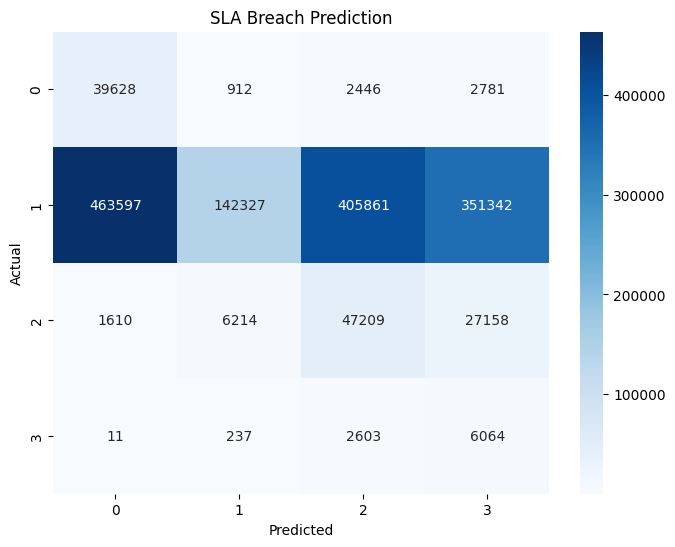

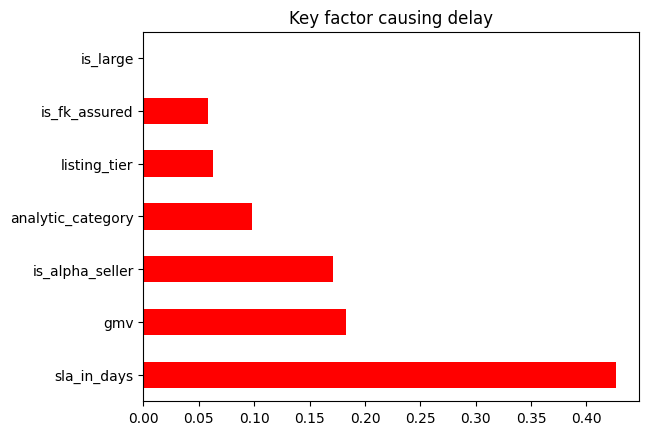

In [8]:
features = ['gmv', 'is_alpha_seller', 'is_fk_assured', 'is_large',
       'sla_in_days', 'listing_tier', 'analytic_category']
X= df[features]
y=df['rts_breach']

#model = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42)
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)

model.fit(X,y)
y_pred = model.predict(X)
accuracy = accuracy_score(y,y_pred)
print(f"Classification Result")
print(f"Model Accuracy: {accuracy:.2f}")
print(classification_report(y, y_pred))

importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
print(importances)

plt.figure(figsize=(8,6))
cm = confusion_matrix(y, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("SLA Breach Prediction")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

importances.plot(kind='barh', color='red', title="Key factor causing delay")
plt.show()

In [18]:
result_df= df.copy()
result_df['Predicted_Breach_Type'] =y_pred
impact_data = result_df[result_df['Predicted_Breach_Type'] !=1]
action_list = impact_data[[ 'analytic_category', 'sla_in_days', 'Predicted_Breach_Type', 'gmv']]
file_path = r"G:\My Drive\New_Working_Files\KNIME\CTU_2026\ML_Models\OMS_Output_confusion.csv"
action_list.to_csv(file_path)
print(f"Successfully exported the data {len(action_list)}")

Successfully exported the data 1350310
